In [ ]:
# 2025.11.29 SGD HyperOpt & Train Result


In [26]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [27]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import hyperopt_search
importlib.reload(hyperopt_search)


from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [28]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [29]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [30]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [31]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [32]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [ ]:
# 5.1 학습/검증 데이터 분리
# X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [33]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)


✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [ ]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
# X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [24]:
# 사용자 Functions import - 에러나서 다시 실행
import importlib
from utils import hyperopt_search
importlib.reload(hyperopt_search)

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [34]:
# 1. SGDClassifier 사용 (LSVC보다 훨씬 빠름)
from sklearn.linear_model import SGDClassifier

sgd_search_space = {
    'loss': hp.choice('loss', ['hinge', 'log_loss', 'modified_huber']),  # hinge=SVM, log_loss=로지스틱
    'penalty': hp.choice('penalty', ['l2', 'l1', 'elasticnet']),  # 정규화 유형
    'alpha': hp.loguniform('alpha', np.log(1e-6), np.log(1e-1)),  # 정규화 강도
    'l1_ratio': hp.uniform('l1_ratio', 0, 1),  # elasticnet일 때 l1 비율
    'max_iter': hp.quniform('max_iter', 1000, 10000, 1000),  # 최대 반복
    'tol': hp.loguniform('tol', np.log(1e-5), np.log(1e-2)),  # 수렴 허용 오차
    'learning_rate': hp.choice('learning_rate', ['constant', 'optimal', 'invscaling', 'adaptive']),
    'eta0': hp.loguniform('eta0', np.log(1e-5), np.log(1e-1)),  # 초기 학습률
    'class_weight': hp.choice('class_weight', [None, 'balanced']),  # 클래스 가중치
}

# SGDClassifier
sgd_search_result = hyperopt_search(
    model_class  = SGDClassifier,
    search_space = sgd_search_space, 
    X_train     = X_train,
    y_train     = y_train,
    max_evals   = 100,  
    save_trials = True,
    verbose     = True
)

  SGDClassifier 하이퍼파라미터 탐색 시작
100%|██████████| 100/100 [30:46<00:00, 18.46s/trial, best loss: -0.9862400809399686]

탐색 완료 시간: 1846.02초 (30.77분)
최적 roc_auc: 0.9862

감지된 choice 파라미터:
  - class_weight: [None, 'balanced'] (타입: list, 길이: 2)
  - learning_rate: ['constant', 'optimal', 'invscaling', 'adaptive'] (타입: list, 길이: 4)
  - loss: ['hinge', 'log_loss', 'modified_huber'] (타입: list, 길이: 3)
  - penalty: ['l2', 'l1', 'elasticnet'] (타입: list, 길이: 3)

최적 하이퍼파라미터:
  - alpha: 3.910947175889396e-05
  - class_weight: None
  - eta0: 0.0024094779453352057
  - l1_ratio: 0.6092668391045077
  - learning_rate: adaptive
  - loss: log_loss
  - max_iter: 6000
  - penalty: elasticnet
  - tol: 1.8099178032063352e-05
  - random_state: 23

✓ Trials 객체 저장 완료: ../models/trials/SGDClassifier_trials_20251130_145804.pkl
✓ 최적 파라미터 저장 완료 (JSON): ../models/trials/SGDClassifier_best_params_20251130_145804.json


In [ ]:

# 결과는 변수에 있으니 수동 저장
# import pickle
# from datetime import datetime

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# with open(f'../models/trials/SGD_manual_save_{timestamp}.pkl', 'wb') as f:
#     pickle.dump(sgd_search_result, f)

# print("✅ 결과 수동 저장 완료!")
# print(sgd_search_result['best_params'])

In [39]:
best_params = sgd_search_result['best_params']
best_params

{'alpha': 3.910947175889396e-05,
 'class_weight': None,
 'eta0': 0.0024094779453352057,
 'l1_ratio': 0.6092668391045077,
 'learning_rate': 'adaptive',
 'loss': 'log_loss',
 'max_iter': 6000,
 'penalty': 'elasticnet',
 'tol': 1.8099178032063352e-05,
 'random_state': 23}

In [ ]:
# best_params 값이 인덱스 그대로 맵핑된 경우
# SGD choice 매핑 정의 - 
# sgd_choice_mappings = {
#     'loss': ['hinge', 'log_loss', 'modified_huber'],
#     'penalty': ['l2', 'l1', 'elasticnet'],
#     'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
#     'class_weight': [None, 'balanced']
# }

# # 변환 함수
# def convert_sgd_params(params, choice_mappings):
#     converted = {}
#     for key, value in params.items():
#         if key in choice_mappings:
#             converted[key] = choice_mappings[key][int(value)]
#         elif key == 'max_iter':
#             converted[key] = int(value)
#         else:
#             converted[key] = float(value) if isinstance(value, np.floating) else value
#     return converted

# # 올바른 파라미터 변환
# sgd_best_params_fixed = convert_sgd_params(
#     sgd_search_result['best_params'], 
#     sgd_choice_mappings
# )

# print("변환된 파라미터:")
# print(sgd_best_params_fixed)

# # 이제 train_and_evaluate에 사용
# from utils.hyperopt_search import train_and_evaluate

# result = train_and_evaluate(
#     model_class=SGDClassifier,
#     params=sgd_best_params_fixed,  # 변환된 파라미터 사용
#     X_train=X_train,
#     y_train=y_train,
#     X_test=X_test,
#     y_test=y_test
# )

In [ ]:
# # 에러나서 우선 추출
# best_params = {
#     'alpha': 3.910947175889396e-05,
#     'class_weight': None,  # 0 → None (첫 번째 옵션)
#     'eta0': 0.0024094779453352057,
#     'l1_ratio': 0.6092668391045077,
#     'learning_rate': 'adaptive',  # 3 → 'adaptive' (네 번째 옵션)
#     'loss': 'log_loss',  # 1 → 'log_loss' (두 번째 옵션)
#     'max_iter': 6000,
#     'penalty': 'elasticnet',  # 2 → 'elasticnet' (세 번째 옵션)
#     'tol': 1.8099178032063352e-05,
#     'random_state': 23
# }



In [ ]:
# # 사용자 Functions import - 에러시!
# import importlib
# from utils import hyperopt_search
# importlib.reload(hyperopt_search)

# from utils.hyperopt_search import extract_best_params_from_trials

# # 1. trials 객체 로드
# trials_path = '../models/trials/SGDClassifier_trials_20251130_021748.pkl'  # 실제 파일명으로 변경

# # 2. choice_mappings 올바르게 정의
# lsvc_choice_mappings = {
#     'class_weight': [None, 'balanced'],
#     'dual': [False, True]
# }
# search_result = extract_best_params_from_trials(
#     trials_path=trials_path,
#     choice_mappings=lsvc_choice_mappings,
#     random_state=23
# )

# print("Best params:", search_result['best_params'])
# print(f"Best score: {search_result['best_score']:.4f}")

In [36]:
# 2단계: 최종 학습 및 평가

final_result = train_and_evaluate(
    model_class = SGDClassifier,
    params      = best_params, # sgd_search_result['best_params'],
    X_train     = X_train,
    y_train     = y_train,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result['result_dict']}")

results['sgd_ho_best'] = final_result['result_dict'] # 시각화용

  SGDClassifier 최종 학습 및 평가
사용 파라미터: {'alpha': 3.910947175889396e-05, 'class_weight': None, 'eta0': 0.0024094779453352057, 'l1_ratio': 0.6092668391045077, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 6000, 'penalty': 'elasticnet', 'tol': 1.8099178032063352e-05, 'random_state': 23}
✓ 학습 완료 (4.32초)

평가 결과:
  - accuracy: 0.9994
  - precision: 0.8667
  - recall: 0.7959
  - f1: 0.8298
  - roc_auc: 0.9680

혼동 행렬:
[[56852    12]
 [   20    78]]

✓ 모델 저장: ../models/SGDClassifier_20251130_150155.pkl (0.00 MB)
✓ 결과 저장: ../results/SGDClassifier_result_20251130_150155.json

완료!
최종 결과: {'AUC': 0.968, '정확도': 0.9994, '정밀도': 0.8667, '재현율': 0.7959, 'F1': 0.8298}


In [40]:
# oversampling한 것으로
final_result_over = train_and_evaluate(
    model_class = SGDClassifier,
    params      = best_params, # sgd_search_result['best_params'],
    X_train     = X_train,
    y_train     = y_train,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result_over['result_dict']}")

results['sgd_ho_best_over'] = final_result_over['result_dict'] # 시각화용

  SGDClassifier 최종 학습 및 평가
사용 파라미터: {'alpha': 3.910947175889396e-05, 'class_weight': None, 'eta0': 0.0024094779453352057, 'l1_ratio': 0.6092668391045077, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 6000, 'penalty': 'elasticnet', 'tol': 1.8099178032063352e-05, 'random_state': 23}
✓ 학습 완료 (4.32초)

평가 결과:
  - accuracy: 0.9994
  - precision: 0.8667
  - recall: 0.7959
  - f1: 0.8298
  - roc_auc: 0.9680

혼동 행렬:
[[56852    12]
 [   20    78]]

✓ 모델 저장: ../models/SGDClassifier_20251130_150315.pkl (0.00 MB)
✓ 결과 저장: ../results/SGDClassifier_result_20251130_150315.json

완료!
최종 결과: {'AUC': 0.968, '정확도': 0.9994, '정밀도': 0.8667, '재현율': 0.7959, 'F1': 0.8298}


In [41]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기 
# StandardScaler 적용

X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)

ss_result = train_and_evaluate(
    model_class = SGDClassifier,
    params      = best_params, # sgd_search_result['best_params'],
    X_train     = X_train_sscaled,
    y_train     = y_train,
    X_test      = X_test_sscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['sgd_ho_best_sscaled'] = ss_result['result_dict'] 

  SGDClassifier 최종 학습 및 평가
사용 파라미터: {'alpha': 3.910947175889396e-05, 'class_weight': None, 'eta0': 0.0024094779453352057, 'l1_ratio': 0.6092668391045077, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 6000, 'penalty': 'elasticnet', 'tol': 1.8099178032063352e-05, 'random_state': 23}
✓ 학습 완료 (3.19초)

평가 결과:
  - accuracy: 0.9994
  - precision: 0.8387
  - recall: 0.7959
  - f1: 0.8168
  - roc_auc: 0.9649

혼동 행렬:
[[56849    15]
 [   20    78]]

✓ 모델 저장: ../models/SGDClassifier_20251130_150326.pkl (0.00 MB)
✓ 결과 저장: ../results/SGDClassifier_result_20251130_150326.json


In [43]:
# Data Scale2 
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
X_train_rscaled = rscaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = rscaler.transform(X_test)         # 테스트 데이터는 transform만

rs_result = train_and_evaluate(
    model_class = SGDClassifier,
    params      = best_params, # sgd_search_result['best_params'],
    X_train     = X_train_rscaled,
    y_train     = y_train,
    X_test      = X_test_rscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['sgd_ho_best_rscaled'] = rs_result['result_dict']

  SGDClassifier 최종 학습 및 평가
사용 파라미터: {'alpha': 3.910947175889396e-05, 'class_weight': None, 'eta0': 0.0024094779453352057, 'l1_ratio': 0.6092668391045077, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 6000, 'penalty': 'elasticnet', 'tol': 1.8099178032063352e-05, 'random_state': 23}
✓ 학습 완료 (3.27초)

평가 결과:
  - accuracy: 0.9994
  - precision: 0.8571
  - recall: 0.7959
  - f1: 0.8254
  - roc_auc: 0.9654

혼동 행렬:
[[56851    13]
 [   20    78]]

✓ 모델 저장: ../models/SGDClassifier_20251130_150345.pkl (0.00 MB)
✓ 결과 저장: ../results/SGDClassifier_result_20251130_150345.json


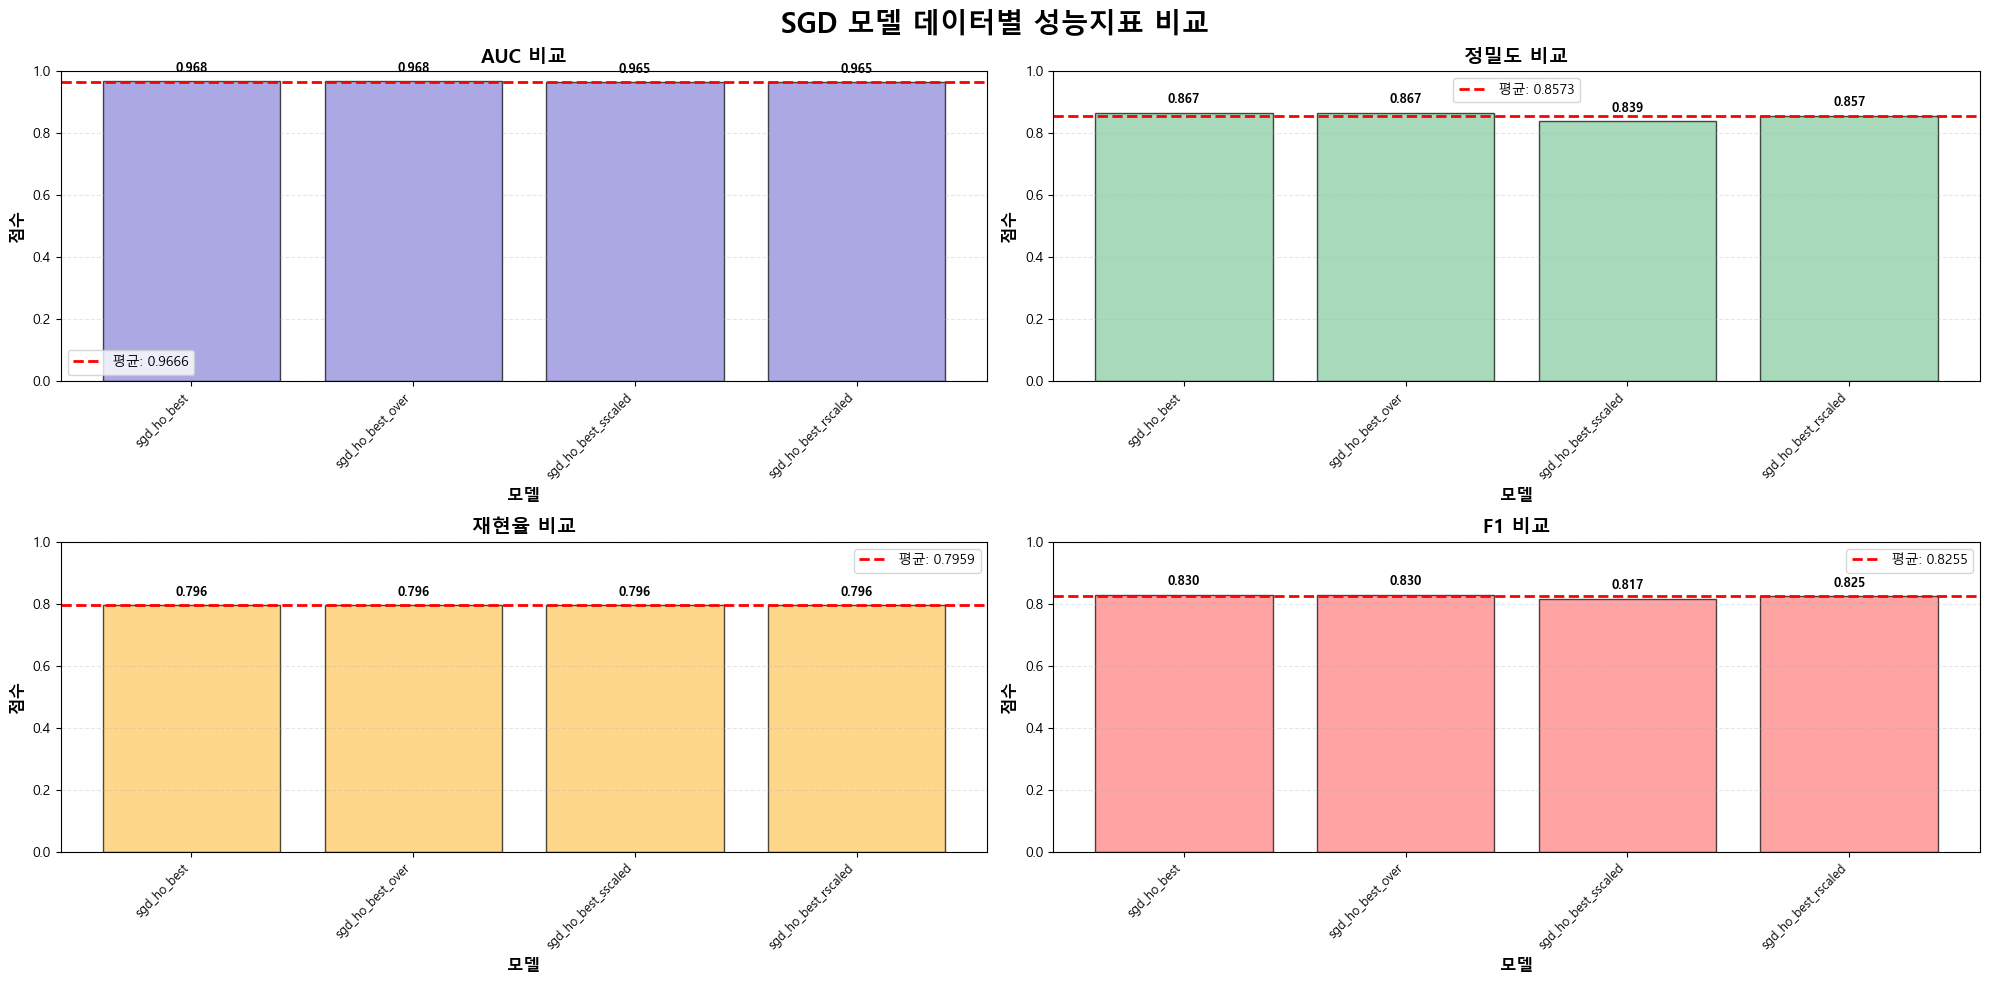


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9680 (sgd_ho_best)
  최저: 0.9649 (sgd_ho_best_sscaled)
  평균: 0.9666
  표준편차: 0.0017

[정밀도]
  최고: 0.8667 (sgd_ho_best)
  최저: 0.8387 (sgd_ho_best_sscaled)
  평균: 0.8573
  표준편차: 0.0132

[재현율]
  최고: 0.7959 (sgd_ho_best)
  최저: 0.7959 (sgd_ho_best)
  평균: 0.7959
  표준편차: 0.0000

[F1]
  최고: 0.8298 (sgd_ho_best)
  최저: 0.8168 (sgd_ho_best_sscaled)
  평균: 0.8255
  표준편차: 0.0061


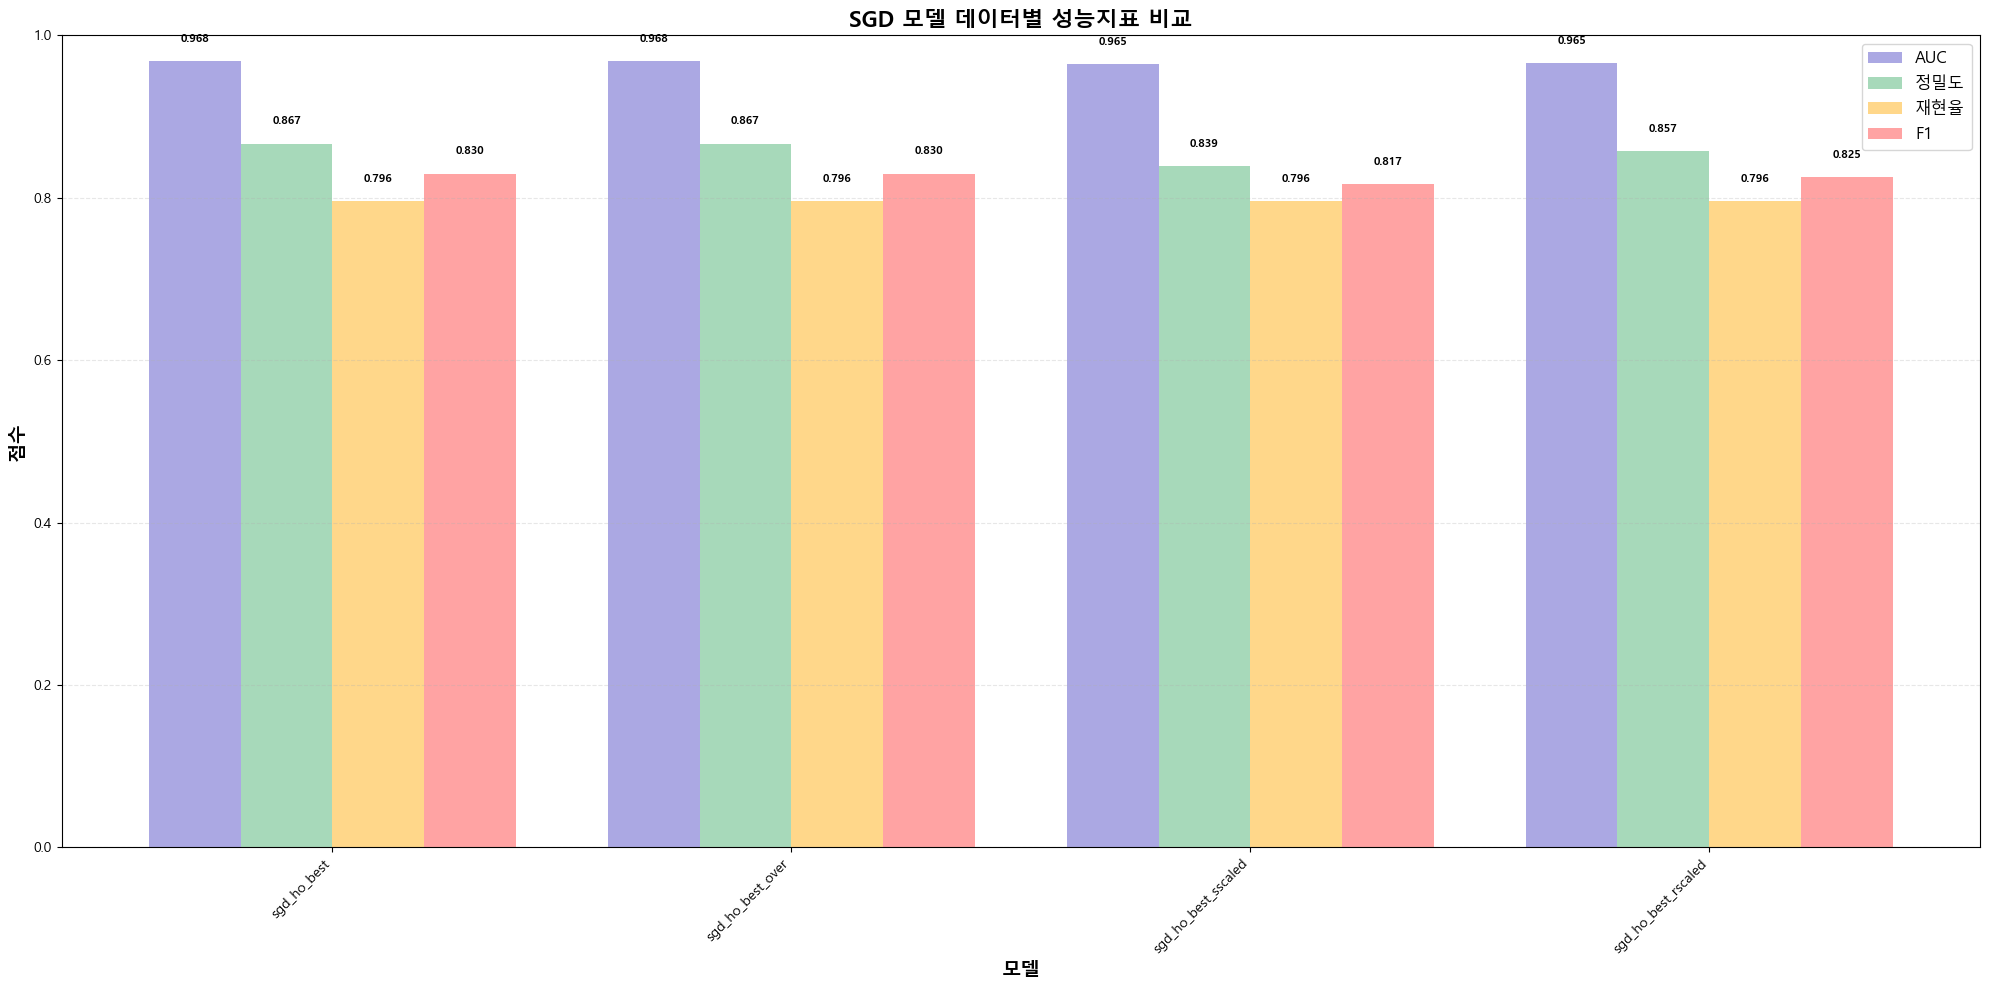


=== F1 Score 기준 상위 5개 모델 ===
                        AUC     정밀도     재현율      F1
sgd_ho_best          0.9680  0.8667  0.7959  0.8298
sgd_ho_best_over     0.9680  0.8667  0.7959  0.8298
sgd_ho_best_rscaled  0.9654  0.8571  0.7959  0.8254
sgd_ho_best_sscaled  0.9649  0.8387  0.7959  0.8168

=== AUC 기준 상위 5개 모델 ===
                        AUC     정밀도     재현율      F1
sgd_ho_best          0.9680  0.8667  0.7959  0.8298
sgd_ho_best_over     0.9680  0.8667  0.7959  0.8298
sgd_ho_best_rscaled  0.9654  0.8571  0.7959  0.8254
sgd_ho_best_sscaled  0.9649  0.8387  0.7959  0.8168

그래프가 저장되었습니다: ../images/SGD_모델_데이터별_성능지표_비교_2025_1130.png


In [44]:
# 7 시각화
mo.model_metrics_graph(results, 'SGD 모델 데이터별 성능지표 비교')